# Linear Regression

In [ ]:
'''
Straight Line
---------------
y = mX + C

y -> Predicted Records
m -> Slope (Change)
X -> Data Points
C -> Intercept (Constant)

Metrics
-----------
- Target Test Data (X-Axis) and Model Predicted Data (Y-Axis)

- MAE (Mean Absolute Error)
    - Sum of distance between best fit line and data points.

- MSE (Mean Squared Error)
    - Sum of square distance between best fit line and data points.

- RMSE (Root Mean Squared Error)
    - Square root of MSE

- R2 Score (Resudial Score)

- If RMSE decreases R2 Score Increases (Correct)
- If RMSE increases R2 Score Decreases

- Linear Regression is sensitive to outliers.

'''

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import model
from sklearn.linear_model import LinearRegression
# to split feature and target data
from sklearn.model_selection import train_test_split
# for scaling of data
from sklearn.preprocessing import StandardScaler
# Import metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv('Dataset/Real estate.csv')
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [3]:
df.isnull().sum()

No                                        0
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


In [5]:
df.columns

Index(['No', 'X1 transaction date', 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'],
      dtype='object')

<Axes: >

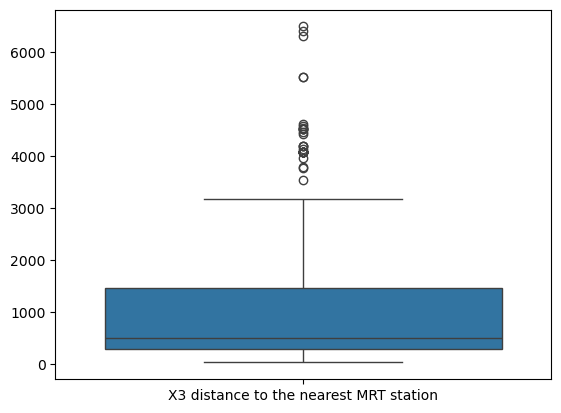

In [6]:
# df = df.drop(columns = ['No', 'X1 transaction date'])
# df
sns.boxplot(df[['X3 distance to the nearest MRT station']]) # < 3100

<Axes: >

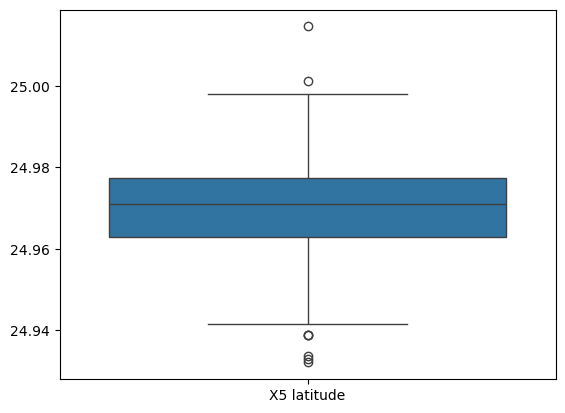

In [7]:
sns.boxplot(df[['X5 latitude']]) #  > 24 and less than 25

<Axes: >

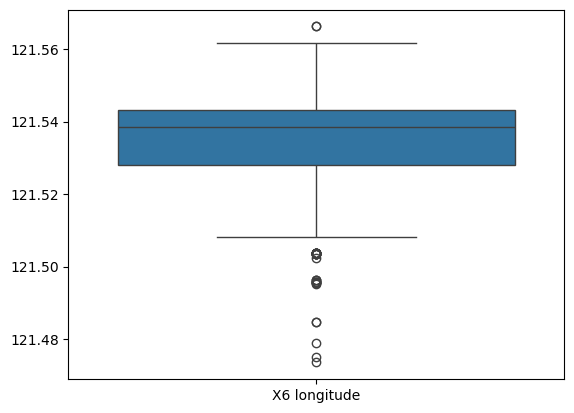

In [8]:
sns.boxplot(df[['X6 longitude']]) # > 121.50

## Using IQR to clean data

In [9]:
# Q1 -> 0.25
# Q2 -> 0.50
# Q3 -> 0.75

# Value under q1 -> Lower Bound
# Value over q3 -> Upper Bound

### df['X3 distance to the nearest MRT station']

In [10]:
q1 = df['X3 distance to the nearest MRT station'].quantile(0.25)
q3 = df['X3 distance to the nearest MRT station'].quantile(0.75)

In [11]:
iqr = q3 - q1

In [12]:
distance_lower_bound = q1 - (1.5 * iqr)
distance_upper_bound = q3 + (1.5 * iqr)

In [13]:
# df = df[df['X3 distance to the nearest MRT station'].between(distance_lower_bound, distance_upper_bound)]
df = df[(df['X3 distance to the nearest MRT station'] >= distance_lower_bound) & 
        (df['X3 distance to the nearest MRT station'] <= distance_upper_bound)]

### df[['X5 latitude']]

In [14]:
q1 = df['X5 latitude'].quantile(0.25)
q3 = df['X5 latitude'].quantile(0.75)

lat_iqr = q3 - q1

lat_lower_bound = q1 - (1.5 * lat_iqr)
lat_upper_bound = q3 + (1.5 * lat_iqr)

In [15]:
df = df[(df['X5 latitude'] >= lat_lower_bound) & (df['X5 latitude'] <= lat_upper_bound)]
# df

### ['X6 longitude']

In [16]:
q1 = df['X6 longitude'].quantile(0.25)
q3 = df['X6 longitude'].quantile(0.75)

lon_iqr = q3 - q1

lon_lower_bound = q1 - (1.5 * lon_iqr)
lon_upper_bound = q3 + (1.5 * lon_iqr)

In [17]:
df = df[(df['X6 longitude'] >= lon_lower_bound) & (df['X6 longitude'] <= lon_upper_bound)]

In [18]:
df

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...,...
406,407,2013.167,1.9,372.13860,7,24.97293,121.54026,40.5
410,411,2012.667,5.6,90.45606,9,24.97433,121.54310,50.0
411,412,2013.250,18.8,390.96960,7,24.97923,121.53986,40.6
412,413,2013.000,8.1,104.81010,5,24.96674,121.54067,52.5


In [19]:
# sns.boxplot(df[['X3 distance to the nearest MRT station']]) # < 3100
# sns.boxplot(df[['X5 latitude']]) #  > 24 and less than 25
# sns.boxplot(df[['X6 longitude']]) # > 121.50

# IQR / Z-Score

In [20]:
# filter_data = df[
#     (df['X3 distance to the nearest MRT station'] < 3100)
#     & (df['X5 latitude'].between(24, 25))
#     & (df['X6 longitude'] > 121.50)
# ]
# filter_data.columns

## Feature and Target

In [21]:
features = ['X2 house age', 'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude']
target = 'Y house price of unit area'

In [22]:
X = df[features]
Y = df[target]

## Train Test Split

In [23]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [24]:
Y_test

269    23.0
44     53.9
209    40.9
101    32.9
121    48.0
       ... 
381    47.3
237    39.0
350    42.3
220    78.3
389    67.7
Name: Y house price of unit area, Length: 63, dtype: float64

## Feature Scaling

In [25]:
'''
-> (Xi - mean)/sd
- fit_transform(X_train) -> [fit -> learning (mean & sd) / transform -> implement]
- transform(X_test) -> [transform -> implement]
'''

'\n-> (Xi - mean)/sd\n- fit_transform(X_train) -> [fit -> learning (mean & sd) / transform -> implement]\n- transform(X_test) -> [transform -> implement]\n'

In [26]:
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

## Define Model

In [27]:
model = LinearRegression()

In [28]:
# Fit learning data to model.
model.fit(X_train_scale, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
# testing test records
Y_pred = model.predict(X_test_scale)

## Metrics

In [30]:
beta_0 = model.intercept_
beta_1 = model.coef_

In [31]:
print(f'Intercept: {beta_0}')
print(f'Slope: {beta_1}')

Intercept: 42.38888888888955
Slope: [-3.54903269 -4.93596231  1.02653205  3.24807193  0.1193727 ]


In [32]:
# metrics(Y_test (actual data), Y_pred (model predicted data))
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)

In [33]:
print(f'Mean Absolute Error: {mae:,.2f}')
print(f'Mean Squared Error: {mse:,.2f}')
print(f'Root Mean Squared Error: {rmse:,.2f}')
print(f'Residual Score: {r2:,.2f}')

Mean Absolute Error: 6.20
Mean Squared Error: 76.88
Root Mean Squared Error: 8.77
Residual Score: 0.53


## Visualization

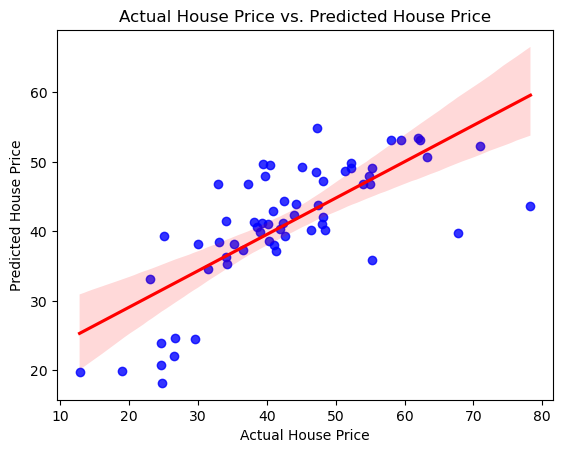

In [34]:
sns.regplot(x=Y_test, y=Y_pred, color='blue', line_kws={'color':'red'})
plt.xlabel('Actual House Price')
plt.ylabel('Predicted House Price')
plt.title('Actual House Price vs. Predicted House Price')
plt.show()

## Random Forest

In [35]:
from sklearn.ensemble import RandomForestRegressor

In [36]:
rf_model = RandomForestRegressor()

In [37]:
rf_model.fit(X_train_scale, Y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [38]:
rf_pred = rf_model.predict(X_test_scale)

In [39]:
rf_mae = mean_absolute_error(Y_test, rf_pred)
rf_mse = mean_squared_error(Y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(Y_test, rf_pred)

In [40]:
print(f'RF Mean Absolute Error: {rf_mae}')
print(f'RF Mean Squared Error: {rf_mse}')
print(f'RF Root Mean Squared Error: {rf_rmse}')
print(f'RF Residual Score: {rf_r2}')

RF Mean Absolute Error: 5.537387191644333
RF Mean Squared Error: 62.27507597036293
RF Root Mean Squared Error: 7.891455884078864
RF Residual Score: 0.6203542519865021


<Axes: xlabel='Y house price of unit area'>

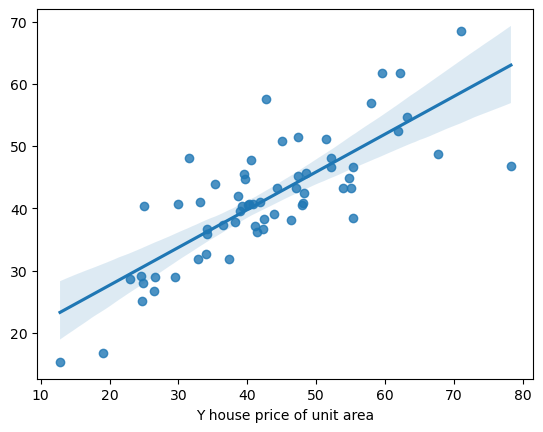

In [41]:
sns.regplot(x=Y_test, y=rf_pred)

In [42]:
'''
Types of Regression Model Evaluation
-------------------------------------
1. Cross Validation (Universal)
    - Mostly used for small or medium size datasets (<= 100000)
    - Model will learn train data 5 to 6 times.
    
2. Polynomial Regression
    - If our feature contains any non-linear pattern.
    - Handles non linear pattern.

3. Ridge Regression
    - Converts high weight features to 0 or close to zero
    
4. Lasso Regression
    - Removes high weight features
    
5. Elastic Net
    - Hybrid Regression -> Combination of Ridge Regression and Lasso Regression
'''

'\nTypes of Regression Model Evaluation\n-------------------------------------\n1. Cross Validation (Universal)\n    - Mostly used for small or medium size datasets (<= 100000)\n    - Model will learn train data 5 to 6 times.\n\n2. Polynomial Regression\n    - If our feature contains any non-linear pattern.\n    - Handles non linear pattern.\n\n3. Ridge Regression\n    - Converts high weight features to 0 or close to zero\n\n4. Lasso Regression\n    - Removes high weight features\n\n5. Elastic Net\n    - Hybrid Regression -> Combination of Ridge Regression and Lasso Regression\n'

In [43]:
'''
Pearson Correlation -> Which only calculates linear pattern.
Spearsman correlation -> Which only calculates and finds non-linear pattern.
'''

'\nPearson Correlation -> Which only calculates linear pattern.\nSpearsman correlation -> Which only calculates and finds non-linear pattern.\n'

In [44]:
# corrleation heatmap
corr_data = df.corr(method='spearman')
# corr_data

<Axes: >

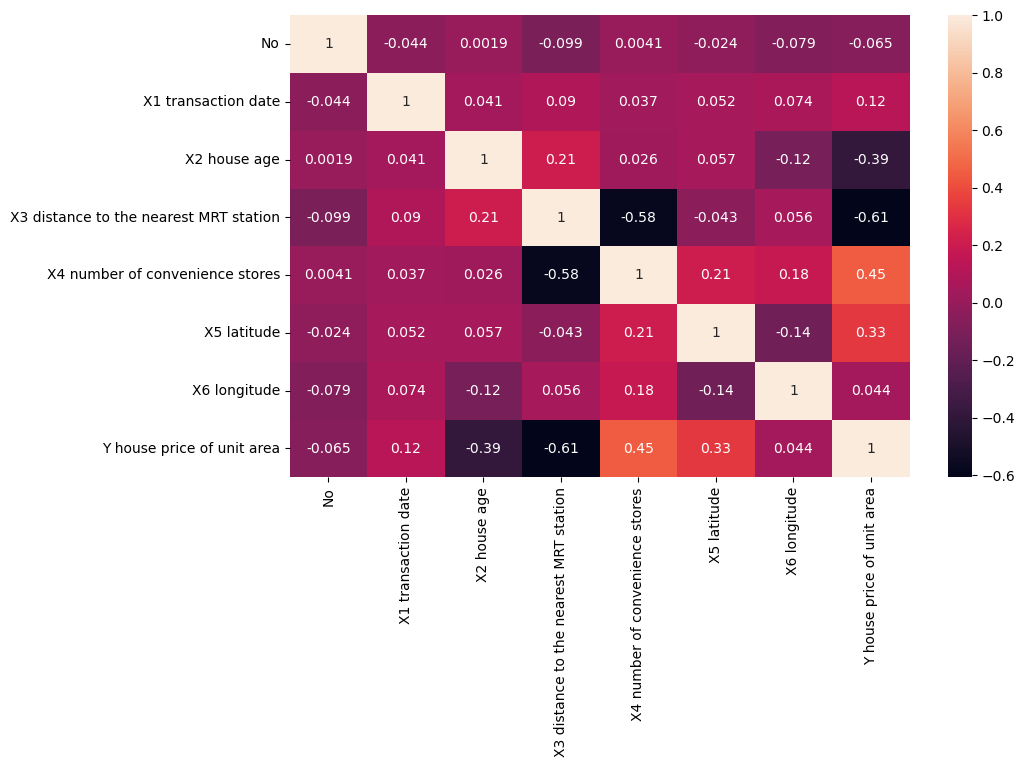

In [45]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_data, annot=True)